# Cinema Intelligence — Feature Engineering

**Dataset**: 59,905 movies × 12 columns | PostgreSQL `cinema_intelligence`  
**Markets**: Hollywood `#3B82F6` | Indian `#F97316`  
**Period**: 2021 – 2025  
**Goal**: End-to-end feature engineering — cleaning, distribution analysis, genre deep dives, and executive synthesis.

---

## Phase 1 — Data Integrity & Health Audit

> Establish a reliable working dataset by connecting to the source, auditing missingness, and removing statistical noise.

---

### Cell 1.1 — Imports, DB Connection & Load `df`

Load all dependencies and pull the Golden Dataset from PostgreSQL.  
The query joins `movies`, `languages`, `movie_genres`, and `genres` tables into a single flat dataframe.


In [1]:
import os
import ast
import pandas as pd
import numpy as np
import psycopg2
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from dotenv import load_dotenv
from pathlib import Path

load_dotenv('../.env')

POSTGRES_HOST = os.getenv("POSTGRES_HOST", os.getenv("DB_HOST", "localhost"))
POSTGRES_PORT = os.getenv("POSTGRES_PORT", os.getenv("DB_PORT", "5432"))
POSTGRES_DB   = os.getenv("POSTGRES_DB",   os.getenv("DB_NAME", "cinema_intelligence"))
POSTGRES_USER = os.getenv("POSTGRES_USER", os.getenv("DB_USER", "cinema_user"))
POSTGRES_PASS = os.getenv("POSTGRES_PASSWORD", os.getenv("DB_PASS", "cinema_password"))

HOLLYWOOD_COLOR = "#3B82F6"
INDIAN_COLOR    = "#F97316"
DARK_BG         = "#0F172A"
CARD_BG         = "#1E293B"
FONT_COLOR      = "#E2E8F0"

IMAGES_PATH = Path("../images/fe")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def get_conn():
    return psycopg2.connect(
        host=POSTGRES_HOST, port=POSTGRES_PORT,
        dbname=POSTGRES_DB, user=POSTGRES_USER, password=POSTGRES_PASS
    )

query = """
    SELECT
        m.movie_id,
        m.external_id,
        m.title,
        m.release_date,
        EXTRACT(YEAR  FROM m.release_date)::INT AS release_year,
        EXTRACT(MONTH FROM m.release_date)::INT AS release_month,
        m.runtime_minutes,
        m.market_type,
        m.rating,
        m.vote_count,
        l.language_name,
        ARRAY_AGG(g.genre_name) FILTER (WHERE g.genre_name IS NOT NULL) AS genres
    FROM movies m
    LEFT JOIN languages    l  ON m.language_id  = l.language_id
    LEFT JOIN movie_genres mg ON m.movie_id      = mg.movie_id
    LEFT JOIN genres       g  ON mg.genre_id     = g.genre_id
    WHERE m.release_date IS NOT NULL
    GROUP BY m.movie_id, m.external_id, m.title, m.release_date,
             m.runtime_minutes, m.market_type, m.rating, m.vote_count, l.language_name
"""

conn = get_conn()
df = pd.read_sql(query, conn)
conn.close()

df["release_date"] = pd.to_datetime(df["release_date"])

print(f"Shape         : {df.shape}")
print(f"Years covered : {df['release_year'].min()} – {df['release_year'].max()}")
print(f"\nMarket split:")
print(df["market_type"].value_counts().to_string())
print(f"\nDtypes:")
print(df.dtypes.to_string())
print(f"\nSample:")
df.head(3)


C:\Users\periy\AppData\Local\Temp\ipykernel_21072\3552453221.py:60: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Shape         : (59905, 12)
Years covered : 2021 – 2025

Market split:
market_type
Hollywood    48595
Indian       11310

Dtypes:
movie_id                   int64
external_id                  str
title                        str
release_date       datetime64[s]
release_year               int64
release_month              int64
runtime_minutes          float64
market_type                  str
rating                   float64
vote_count               float64
language_name                str
genres                    object

Sample:


,movie_id,external_id,title,release_date,release_year,release_month,runtime_minutes,market_type,rating,vote_count,language_name,genres
0,1,tt26929417,Birthing Justice,2023-01-01,2023,1,96.0,Hollywood,6.3,15.0,English,[Documentary]
1,2,tt28634153,Broken Mary: The Kevin Matthews Story,2025-01-01,2025,1,64.0,Hollywood,9.2,23.0,English,[Documentary]
2,3,tt7720142,Assassin Club,2023-01-01,2023,1,111.0,Indian,4.7,4090.0,Hindi,"[Thriller, Action]"



### Cell 1.2 — Missingness Bar Chart

Audit every column for null values and visualise sparsity as a horizontal bar chart.

**Key findings**:
- `rating` and `vote_count` — 34.19% missing (unrated movies)
- `runtime_minutes` — 24.17% missing
- `genres` — 3.06% missing



=== Sparsity Summary ===
                 missing_count  missing_pct
genres                    1836         3.06
runtime_minutes          14481        24.17
rating                   20484        34.19
vote_count               20484        34.19

Total columns with any missing: 4


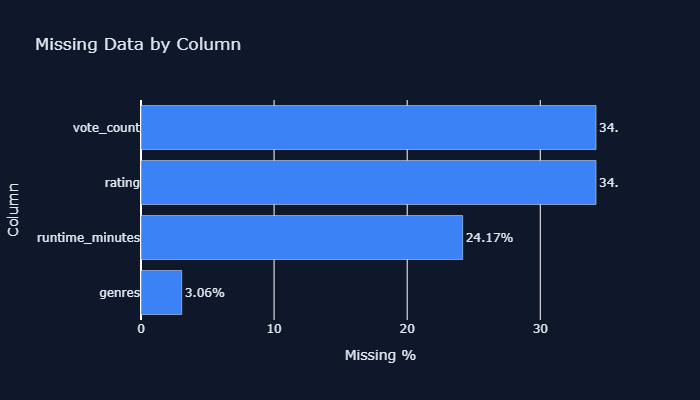

In [2]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
miss_df = miss_df[miss_df["missing_count"] > 0].sort_values("missing_pct", ascending=True)

print("=== Sparsity Summary ===")
print(miss_df.to_string())
print(f"\nTotal columns with any missing: {len(miss_df)}")

fig = go.Figure(go.Bar(
    x=miss_df["missing_pct"],
    y=miss_df.index,
    orientation="h",
    marker_color=HOLLYWOOD_COLOR,
    text=miss_df["missing_pct"].apply(lambda x: f"{x:.2f}%"),
    textposition="outside"
))
fig.update_layout(
    title="Missing Data by Column",
    xaxis_title="Missing %",
    yaxis_title="Column",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    height=400
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "1.2_missingness.png"), scale=2)



---

### Cell 1.3 — Outlier Removal & Credibility Filter

Apply two production-grade filters to create `df_clean`:

| Filter | Rule | Rationale |
|--------|------|-----------|
| Runtime outlier | `runtime_minutes ≤ 400` | Removes data-entry errors |
| Credibility threshold | `vote_count ≥ 50` | Minimum statistical reliability |


In [3]:
shape_before = df.shape

df_clean = df[
    (df["runtime_minutes"].isna() | (df["runtime_minutes"] <= 400)) &
    (df["vote_count"].isna() | (df["vote_count"] >= 50))
].copy()

shape_after = df_clean.shape
rows_removed = shape_before[0] - shape_after[0]

print(f"Shape before : {shape_before}")
print(f"Shape after  : {shape_after}")
print(f"Rows removed : {rows_removed}")
print(f"\nMarket split (clean):")
print(df_clean["market_type"].value_counts().to_string())
print(f"\nRuntime max  : {df_clean['runtime_minutes'].max()}")
print(f"Vote min     : {df_clean['vote_count'].min()}")


Shape before : (59905, 12)
Shape after  : (45882, 12)
Rows removed : 14023

Market split (clean):
market_type
Hollywood    36233
Indian        9649

Runtime max  : 396.0
Vote min     : 50.0



---

## Phase 2 — Univariate & Market Volume Analysis

> Understand production volume patterns across years and markets.

---

### Cell 2.1 — Production Velocity: Releases Per Year

Group `df_clean` by `release_year` and `market_type` to show annual output trends.


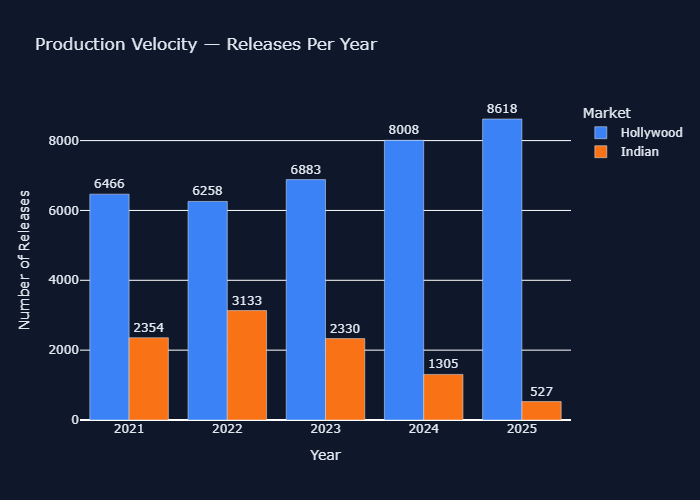

In [4]:
yearly = (
    df_clean.groupby(["release_year", "market_type"])
    .size()
    .reset_index(name="count")
)

fig = px.bar(
    yearly,
    x="release_year",
    y="count",
    color="market_type",
    barmode="group",
    color_discrete_map={"Hollywood": HOLLYWOOD_COLOR, "Indian": INDIAN_COLOR},
    text="count",
    title="Production Velocity — Releases Per Year"
)
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of Releases",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    legend_title="Market",
    xaxis=dict(tickmode="linear"),
    height=500
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "2.1_releases_per_year.png"), scale=2)



---

### Cell 2.2 — Runtime Distribution by Market

> **Data limitation**: All `release_date` values are stored as Jan 1st (year-only precision in the DB).  
> A monthly releases chart is not feasible. Replaced with **Runtime Distribution by Market**.

Violin + box plot comparing runtime spread across Hollywood and Indian cinema.


Movies with runtime data: 34,972
               count   mean   std   min   25%    50%    75%    max
market_type                                                       
Hollywood    27097.0   93.5  27.3   1.0  78.0   91.0  106.0  396.0
Indian        7875.0  111.3  25.6  45.0  93.0  110.0  128.5  395.0


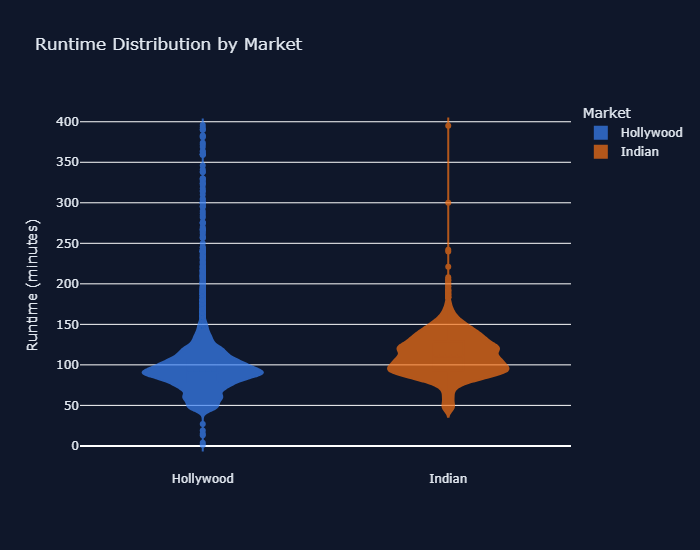

In [5]:
df_runtime = df_clean.dropna(subset=["runtime_minutes"])

print(f"Movies with runtime data: {len(df_runtime):,}")
print(df_runtime.groupby("market_type")["runtime_minutes"].describe().round(1).to_string())

fig = go.Figure()

for market, color in [("Hollywood", HOLLYWOOD_COLOR), ("Indian", INDIAN_COLOR)]:
    subset = df_runtime[df_runtime["market_type"] == market]["runtime_minutes"]
    fig.add_trace(go.Violin(
        y=subset,
        name=market,
        box_visible=True,
        meanline_visible=True,
        fillcolor=color,
        opacity=0.7,
        line_color=color
    ))

fig.update_layout(
    title="Runtime Distribution by Market",
    yaxis_title="Runtime (minutes)",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    legend_title="Market",
    height=550,
    violingap=0.3
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "2.2_runtime_distribution.png"), scale=2)



---

### Cell 2.3 — Market Share Donut Chart

Proportional breakdown of the credible dataset by market.


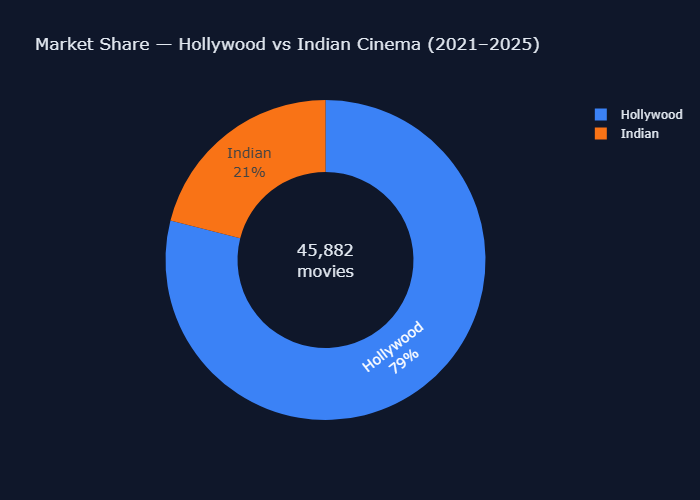

In [6]:
market_counts = df_clean["market_type"].value_counts().reset_index()
market_counts.columns = ["market_type", "count"]
market_counts["pct"] = (market_counts["count"] / market_counts["count"].sum() * 100).round(1)

fig = go.Figure(go.Pie(
    labels=market_counts["market_type"],
    values=market_counts["count"],
    hole=0.55,
    marker_colors=[HOLLYWOOD_COLOR, INDIAN_COLOR],
    textinfo="label+percent",
    textfont_size=14,
    hovertemplate="%{label}: %{value:,} movies (%{percent})<extra></extra>"
))

fig.update_layout(
    title="Market Share — Hollywood vs Indian Cinema (2021–2025)",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    height=500,
    annotations=[dict(
        text=f"{market_counts['count'].sum():,}<br>movies",
        x=0.5, y=0.5,
        font_size=16,
        font_color=FONT_COLOR,
        showarrow=False
    )]
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "2.3_market_share_donut.png"), scale=2)



---

## Phase 3 — Distribution & Statistical Rigor

> Move beyond means — test whether observed differences are statistically reliable.

---

### Cell 3.1 — Rating Distributions (Overlaid Histogram)

Probability-density histogram of IMDb ratings for both markets overlaid on the same chart.

| Market | n | Mean | Median |
|--------|---|------|--------|
| Hollywood | 18,259 | 5.90 | 6.00 |
| Indian | 7,158 | 5.98 | 6.10 |

Visually the distributions are nearly identical — peaked around 6.0 for both markets.


Movies with ratings: 25,417
               count  mean   std  min  25%  50%  75%  max
market_type                                              
Hollywood    18259.0  5.90  1.47  1.0  5.0  6.0  6.9  9.9
Indian        7158.0  5.98  1.45  1.0  5.0  6.1  7.0  9.6


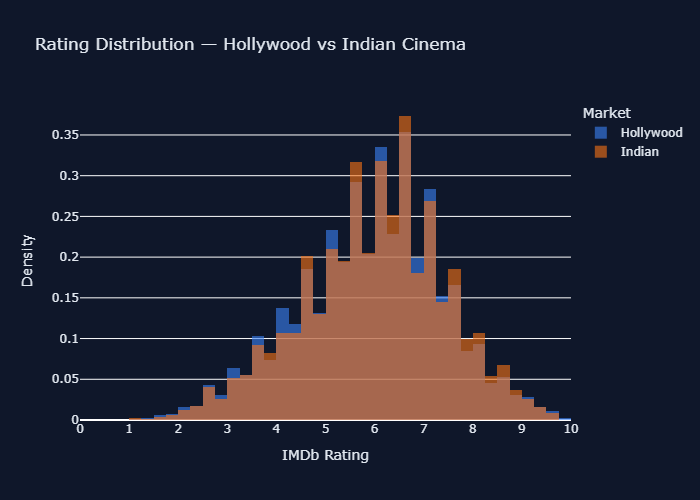

In [7]:
df_rated = df_clean.dropna(subset=["rating"])

print(f"Movies with ratings: {len(df_rated):,}")
print(df_rated.groupby("market_type")["rating"].describe().round(2).to_string())

fig = go.Figure()

for market, color in [("Hollywood", HOLLYWOOD_COLOR), ("Indian", INDIAN_COLOR)]:
    subset = df_rated[df_rated["market_type"] == market]["rating"]
    fig.add_trace(go.Histogram(
        x=subset,
        name=market,
        opacity=0.6,
        marker_color=color,
        histnorm="probability density",
        nbinsx=40,
        xbins=dict(start=0, end=10, size=0.25)
    ))

fig.update_layout(
    title="Rating Distribution — Hollywood vs Indian Cinema",
    xaxis_title="IMDb Rating",
    yaxis_title="Density",
    barmode="overlay",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    legend_title="Market",
    height=500,
    xaxis=dict(range=[0, 10], dtick=1)
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "3.1_rating_distributions.png"), scale=2)



---

### Cell 3.2 — Mann-Whitney U Test on Ratings

Non-parametric two-sided test (no normality assumption required).

| Metric | Value |
|--------|-------|
| U-statistic | 63,623,572 |
| p-value | 0.001038 |
| Effect size (rank-biserial r) | 0.0264 |
| Result | **Significant** — Indian cinema rates statistically higher |

> **Interpretation**: Statistically significant due to large sample size, but the effect size (~0.026) is negligible. The practical difference in ratings between markets is minimal.

In [8]:
hw_ratings = df_rated[df_rated["market_type"] == "Hollywood"]["rating"].dropna()
in_ratings = df_rated[df_rated["market_type"] == "Indian"]["rating"].dropna()

u_stat, p_value = stats.mannwhitneyu(hw_ratings, in_ratings, alternative="two-sided")

effect_size = 1 - (2 * u_stat) / (len(hw_ratings) * len(in_ratings))

print("=== Mann-Whitney U Test: Hollywood vs Indian Ratings ===")
print(f"Hollywood  n = {len(hw_ratings):,}  |  mean = {hw_ratings.mean():.3f}  |  median = {hw_ratings.median():.3f}")
print(f"Indian     n = {len(in_ratings):,}  |  mean = {in_ratings.mean():.3f}  |  median = {in_ratings.median():.3f}")
print(f"\nU-statistic : {u_stat:,.0f}")
print(f"p-value     : {p_value:.6f}")
print(f"Effect size : {effect_size:.4f}  (Rank-biserial correlation)")

if p_value < 0.05:
    direction = "Indian" if in_ratings.median() > hw_ratings.median() else "Hollywood"
    print(f"\nResult : SIGNIFICANT (p < 0.05) — {direction} cinema rates statistically higher")
else:
    print(f"\nResult : NOT significant (p ≥ 0.05) — no reliable rating difference between markets")


=== Mann-Whitney U Test: Hollywood vs Indian Ratings ===
Hollywood  n = 18,259  |  mean = 5.904  |  median = 6.000
Indian     n = 7,158  |  mean = 5.976  |  median = 6.100

U-statistic : 63,623,572
p-value     : 0.001038
Effect size : 0.0264  (Rank-biserial correlation)

Result : SIGNIFICANT (p < 0.05) — Indian cinema rates statistically higher



---

### Cell 3.3 — Runtime Evolution Per Year by Market

Median runtime tracked year-by-year for each market using a line chart.

| Year | Hollywood (min) | Indian (min) |
|------|----------------|--------------|
| 2021 | 89 | 104 |
| 2022 | 90 | 107 |
| 2023 | 91 | 115 |
| 2024 | 94 | 115 |
| 2025 | 95 | 120 |

**Key finding**: Both markets are getting longer. The gap is **widening** — Indian cinema is diverging upward faster.


 release_year market_type  median_runtime  count
         2021   Hollywood            89.0   4647
         2021      Indian           104.0   1939
         2022   Hollywood            90.0   4431
         2022      Indian           107.0   2643
         2023   Hollywood            91.0   5284
         2023      Indian           115.0   1945
         2024   Hollywood            94.0   6247
         2024      Indian           115.0   1023
         2025   Hollywood            95.0   6488
         2025      Indian           120.0    325


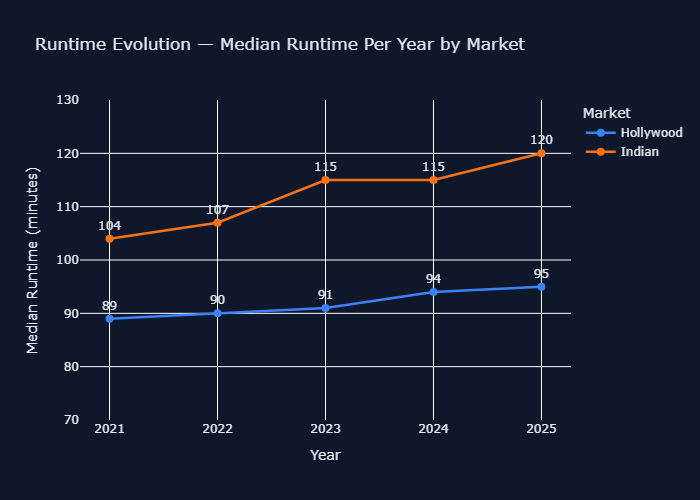

In [9]:
runtime_yearly = (
    df_clean.dropna(subset=["runtime_minutes"])
    .groupby(["release_year", "market_type"])["runtime_minutes"]
    .agg(median_runtime="median", count="size")
    .reset_index()
)

print(runtime_yearly.to_string(index=False))

fig = px.line(
    runtime_yearly,
    x="release_year",
    y="median_runtime",
    color="market_type",
    markers=True,
    color_discrete_map={"Hollywood": HOLLYWOOD_COLOR, "Indian": INDIAN_COLOR},
    text="median_runtime",
    title="Runtime Evolution — Median Runtime Per Year by Market"
)
fig.update_traces(textposition="top center", line_width=2.5, marker_size=8)
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Median Runtime (minutes)",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    legend_title="Market",
    xaxis=dict(tickmode="linear"),
    yaxis=dict(range=[70, 130]),
    height=500
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "3.3_runtime_evolution.png"), scale=2)



---

## Phase 4 — Bivariate & Categorical Deep Dives

> Explode the genre dimension and analyse growth trends and market sentiment across genres.

---

### Cell 4.1 — Genre Explosion

Parse `genres` column (Python list strings) using `ast.literal_eval` then `explode()` into long-form rows.


In [10]:
df_genre_raw = df_clean.dropna(subset=["genres"]).copy()

df_genre_raw["genres_parsed"] = df_genre_raw["genres"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_genre = df_genre_raw.explode("genres_parsed").rename(columns={"genres_parsed": "genre"})
df_genre = df_genre[df_genre["genre"].notna() & (df_genre["genre"].str.strip() != "")].copy()

print(f"df_genre shape     : {df_genre.shape}")
print(f"Unique genres      : {df_genre['genre'].nunique()}")
print(f"Top 10 genres:")
print(df_genre["genre"].value_counts().head(10).to_string())


df_genre shape     : (71075, 13)
Unique genres      : 26
Top 10 genres:
genre
Drama          16569
Documentary     9322
Comedy          8273
Thriller        5932
Horror          5304
Action          4508
Crime           3195
Romance         3188
Mystery         2053
Adventure       1966



---

### Cell 4.2 — Genre Growth / Decline %

Compare genre volume between the **first 2-year window (2021–22)** and the **last 2-year window (2023–24)** to surface structural market shifts.

**Growing genres** (top 3):
- Western: +36.2%
- War: +18.8%
- Thriller: +12.0%

**Declining genres** (top 3):
- Adult: -49.2%
- Reality-TV: -39.3%
- Mystery: -14.3%

> Audience appetite is shifting toward grittier, tension-driven genres (Thriller, War, Western) and away from soft entertainment (Reality-TV, Adult, Musical).


=== Genre Growth/Decline (2021-22 → 2023-24) ===
              early  late  pct_change
genre                                
News           14.0     6       -57.1
Adult         130.0    66       -49.2
Reality-TV     28.0    17       -39.3
Mystery       913.0   782       -14.3
Fantasy       555.0   488       -12.1
Musical       191.0   171       -10.5
Romance      1314.0  1257        -4.3
Music         449.0   434        -3.3
Adventure     803.0   777        -3.2
Sport         318.0   308        -3.1
History       404.0   394        -2.5
Drama        6835.0  6688        -2.2
Documentary  3753.0  3715        -1.0
Biography     555.0   551        -0.7
Talk-Show      16.0    16         0.0
Family        573.0   585         2.1
Sci-Fi        574.0   590         2.8
Horror       2067.0  2158         4.4
Animation     493.0   516         4.7
Crime        1259.0  1324         5.2
Comedy       3215.0  3527         9.7
Action       1724.0  1894         9.9
Thriller     2228.0  2495        12.0
W

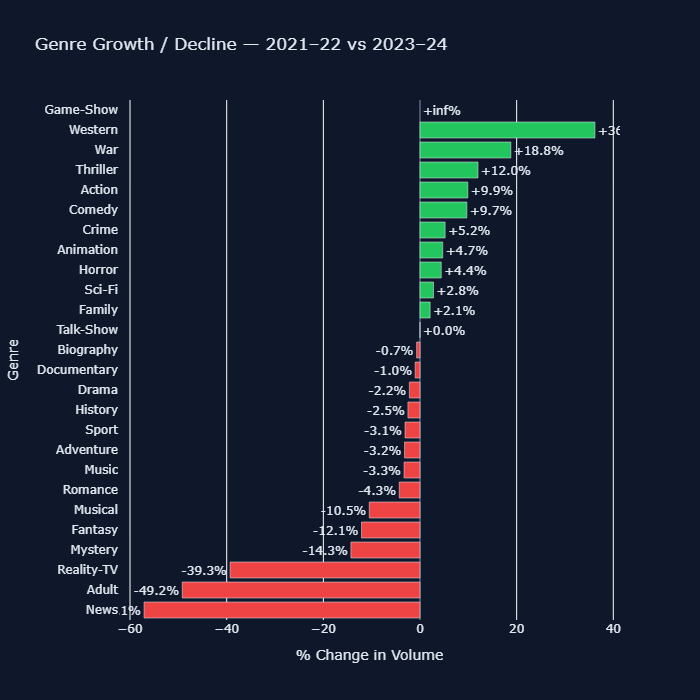

In [11]:
early = df_genre[df_genre["release_year"].isin([2021, 2022])]
late  = df_genre[df_genre["release_year"].isin([2023, 2024])]

early_counts = early["genre"].value_counts().rename("early")
late_counts  = late["genre"].value_counts().rename("late")

growth_df = pd.concat([early_counts, late_counts], axis=1).fillna(0)
growth_df["pct_change"] = ((growth_df["late"] - growth_df["early"]) / growth_df["early"] * 100).round(1)
growth_df = growth_df.sort_values("pct_change", ascending=True)

print("=== Genre Growth/Decline (2021-22 → 2023-24) ===")
print(growth_df[["early", "late", "pct_change"]].to_string())

colors = ["#EF4444" if v < 0 else "#22C55E" for v in growth_df["pct_change"]]

fig = go.Figure(go.Bar(
    x=growth_df["pct_change"],
    y=growth_df.index,
    orientation="h",
    marker_color=colors,
    text=growth_df["pct_change"].apply(lambda x: f"{x:+.1f}%"),
    textposition="outside"
))
fig.update_layout(
    title="Genre Growth / Decline — 2021–22 vs 2023–24",
    xaxis_title="% Change in Volume",
    yaxis_title="Genre",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    height=700,
    xaxis=dict(zeroline=True, zerolinecolor="#475569", zerolinewidth=2)
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "4.2_genre_growth.png"), scale=2)



---

### Cell 4.3 — Market Sentiment: Avg Rating Per Genre

Grouped bar chart showing average IMDb rating per genre, split by market.  
Only genres with **≥ 50 movies per market** included (21 genres qualify).

**Key findings**:
- Indian cinema consistently rates slightly higher than Hollywood across most genres
- Top-rated genres (both markets): Music (~7.0), Documentary (~7.0), Biography (~6.75), Sport (~6.75)
- Bottom-rated genres: Horror (~4.6–4.9), Sci-Fi (~4.9–5.0), Thriller (~5.3–5.6)


Genres shown (≥50 movies per market): 21
      genre market_type  avg_rating  count
     Action   Hollywood        5.43   1828
     Action      Indian        5.73   1457
  Adventure   Hollywood        5.63    863
  Adventure      Indian        5.84    560
  Animation   Hollywood        6.29    530
  Animation      Indian        6.38    241
  Biography   Hollywood        6.71    776
  Biography      Indian        6.88    253
     Comedy   Hollywood        5.77   4046
     Comedy      Indian        5.90   1718
      Crime   Hollywood        5.83   1488
      Crime      Indian        6.03    934
Documentary   Hollywood        7.02   2975
Documentary      Indian        6.90    373
      Drama   Hollywood        6.09   7556
      Drama      Indian        6.19   3632
     Family   Hollywood        6.01    653
     Family      Indian        6.34    325
    Fantasy   Hollywood        5.62    629
    Fantasy      Indian        5.70    276
    History   Hollywood        6.60    572
    History  

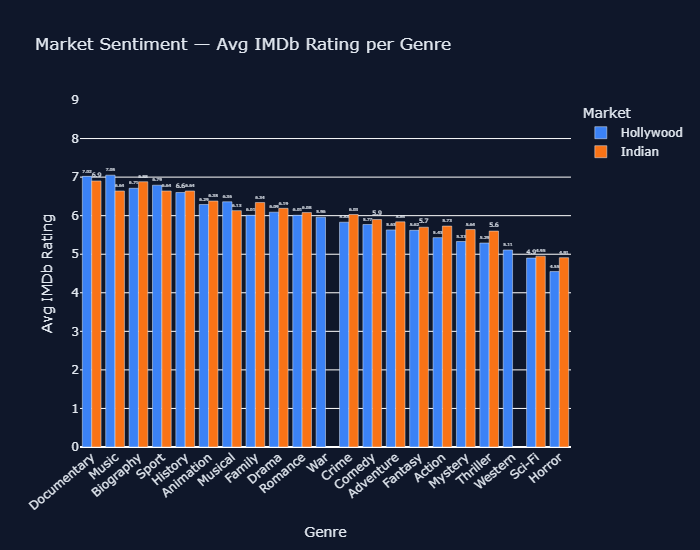

In [12]:
sentiment = (
    df_genre.dropna(subset=["rating"])
    .groupby(["genre", "market_type"])["rating"]
    .agg(avg_rating="mean", count="size")
    .reset_index()
)

min_movies = 50
sentiment = sentiment[sentiment["count"] >= min_movies]
sentiment["avg_rating"] = sentiment["avg_rating"].round(2)

genre_order = (
    sentiment.groupby("genre")["avg_rating"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

print(f"Genres shown (≥{min_movies} movies per market): {sentiment['genre'].nunique()}")
print(sentiment.sort_values(["genre","market_type"]).to_string(index=False))

fig = px.bar(
    sentiment,
    x="genre",
    y="avg_rating",
    color="market_type",
    barmode="group",
    color_discrete_map={"Hollywood": HOLLYWOOD_COLOR, "Indian": INDIAN_COLOR},
    text="avg_rating",
    title="Market Sentiment — Avg IMDb Rating per Genre",
    category_orders={"genre": genre_order}
)
fig.update_traces(textposition="outside", textfont_size=10)
fig.update_layout(
    xaxis_title="Genre",
    yaxis_title="Avg IMDb Rating",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    legend_title="Market",
    yaxis=dict(range=[0, 9]),
    height=550,
    xaxis_tickangle=-40
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "4.3_market_sentiment.png"), scale=2)



---

## Phase 5 — Advanced Metrics & Niche Discovery

> Apply information theory and quadrant analysis to uncover hidden market structure.

---

### Cell 5.1 — Shannon Entropy of Genre Distribution

Measures genre **diversity** per market per year using Shannon Entropy (bits).  
Higher entropy = more evenly spread across genres.

| Year | Hollywood | Indian |
|------|-----------|--------|
| 2021 | 3.676 | 3.590 |
| 2022 | 3.657 | 3.599 |
| 2023 | 3.677 | 3.563 |
| 2024 | 3.674 | 3.601 |
| 2025 | 3.659 | 3.567 |


 release_year market_type  entropy
         2021   Hollywood   3.6764
         2022   Hollywood   3.6566
         2023   Hollywood   3.6765
         2024   Hollywood   3.6738
         2025   Hollywood   3.6593
         2021      Indian   3.5897
         2022      Indian   3.5993
         2023      Indian   3.5630
         2024      Indian   3.6010
         2025      Indian   3.5666


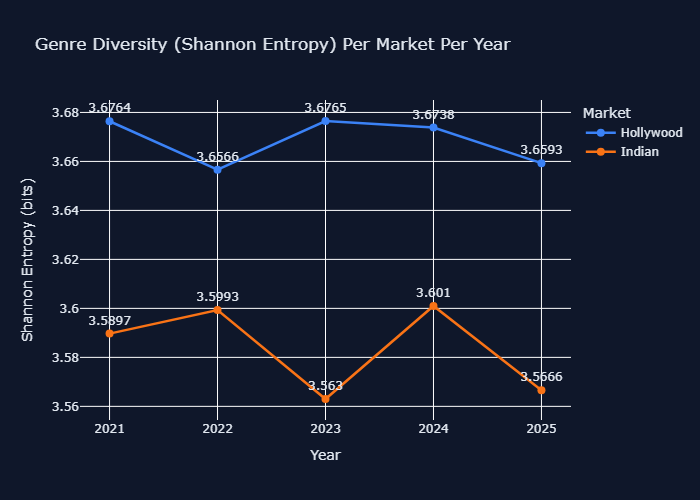

In [13]:
from scipy.stats import entropy as shannon_entropy

entropy_rows = []

for (year, market), grp in df_genre.groupby(["release_year", "market_type"]):
    counts = grp["genre"].value_counts()
    probs = counts / counts.sum()
    ent = shannon_entropy(probs, base=2)
    entropy_rows.append({"release_year": year, "market_type": market, "entropy": round(ent, 4)})

entropy_df = pd.DataFrame(entropy_rows).sort_values(["market_type", "release_year"])
print(entropy_df.to_string(index=False))

fig = px.line(
    entropy_df,
    x="release_year",
    y="entropy",
    color="market_type",
    markers=True,
    color_discrete_map={"Hollywood": HOLLYWOOD_COLOR, "Indian": INDIAN_COLOR},
    text="entropy",
    title="Genre Diversity (Shannon Entropy) Per Market Per Year"
)
fig.update_traces(textposition="top center", line_width=2.5, marker_size=8)
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Shannon Entropy (bits)",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    legend_title="Market",
    xaxis=dict(tickmode="linear"),
    height=500
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "5.1_genre_entropy.png"), scale=2)


---

### Cell 5.2 — Niche Gems Quadrant

Scatter plot placing each genre on two axes:
- **X-axis**: Number of movies (volume)
- **Y-axis**: Avg IMDb rating (quality)

Quadrant lines drawn at median volume (926) and median rating (6.08).

| Quadrant | Genres |
|----------|--------|
| **Niche Gem** (high quality, low volume) | Music, Sport, History, Animation, Musical |
| **Mainstream Quality** (high quality, high volume) | Documentary, Biography, Drama, Family |
| **High Volume Low Quality** | Horror, Thriller, Action, Comedy, Sci-Fi, Crime |
| **Low Volume Low Quality** | War, Fantasy, Western, Adult |

> **Opportunity**: Music, Sport, and History are underserved — high audience satisfaction but limited supply.


Median volume : 926 | Median rating : 6.08
      genre  avg_rating  movie_count                quadrant
 Reality-TV        7.39           12               Niche Gem
       News        7.25            8               Niche Gem
  Game-Show        7.10            1               Niche Gem
Documentary        7.00         3348      Mainstream Quality
      Music        6.98          646               Niche Gem
      Sport        6.75          443               Niche Gem
  Biography        6.75         1029      Mainstream Quality
  Talk-Show        6.73            3               Niche Gem
    History        6.61          751               Niche Gem
  Animation        6.32          771               Niche Gem
    Musical        6.29          222               Niche Gem
      Drama        6.12        11188      Mainstream Quality
     Family        6.12          978      Mainstream Quality
    Romance        6.04         2524 High Volume Low Quality
        War        5.93          236  Low 

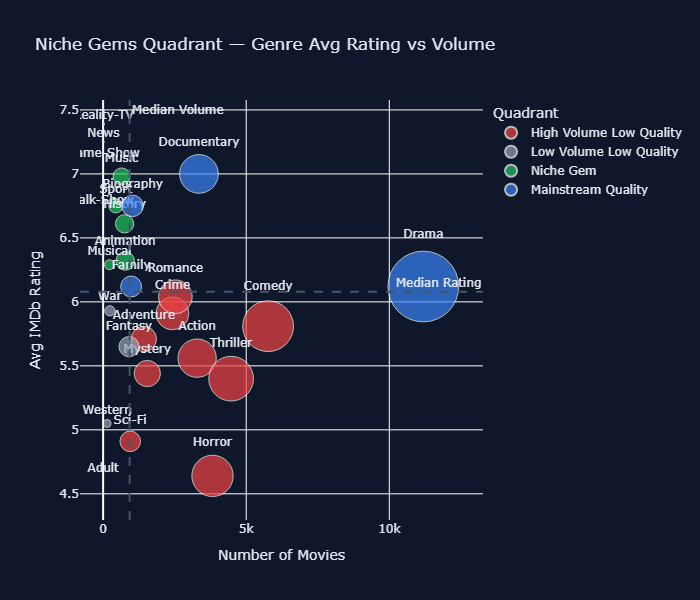

In [14]:
quadrant_df = (
    df_genre.dropna(subset=["rating"])
    .groupby("genre")
    .agg(
        avg_rating=("rating", "mean"),
        movie_count=("genre", "size")
    )
    .reset_index()
)
quadrant_df["avg_rating"] = quadrant_df["avg_rating"].round(2)

med_count  = quadrant_df["movie_count"].median()
med_rating = quadrant_df["avg_rating"].median()

def get_quadrant(row):
    if row["avg_rating"] >= med_rating and row["movie_count"] < med_count:
        return "Niche Gem"
    elif row["avg_rating"] >= med_rating and row["movie_count"] >= med_count:
        return "Mainstream Quality"
    elif row["avg_rating"] < med_rating and row["movie_count"] >= med_count:
        return "High Volume Low Quality"
    else:
        return "Low Volume Low Quality"

quadrant_df["quadrant"] = quadrant_df.apply(get_quadrant, axis=1)

print(f"Median volume : {med_count:.0f} | Median rating : {med_rating:.2f}")
print(quadrant_df.sort_values("avg_rating", ascending=False).to_string(index=False))

QUAD_COLORS = {
    "Niche Gem": "#22C55E",
    "Mainstream Quality": HOLLYWOOD_COLOR,
    "High Volume Low Quality": "#EF4444",
    "Low Volume Low Quality": "#94A3B8"
}

fig = px.scatter(
    quadrant_df,
    x="movie_count",
    y="avg_rating",
    text="genre",
    color="quadrant",
    color_discrete_map=QUAD_COLORS,
    size="movie_count",
    size_max=50,
    title="Niche Gems Quadrant — Genre Avg Rating vs Volume"
)
fig.update_traces(textposition="top center")
fig.add_vline(x=med_count, line_dash="dash", line_color="#475569", annotation_text="Median Volume", annotation_font_color=FONT_COLOR)
fig.add_hline(y=med_rating, line_dash="dash", line_color="#475569", annotation_text="Median Rating", annotation_font_color=FONT_COLOR)
fig.update_layout(
    xaxis_title="Number of Movies",
    yaxis_title="Avg IMDb Rating",
    plot_bgcolor=DARK_BG,
    paper_bgcolor=DARK_BG,
    font_color=FONT_COLOR,
    legend_title="Quadrant",
    height=600
)
fig.show(renderer="png")
fig.write_image(str(IMAGES_PATH / "5.2_niche_gems.png"), scale=2)



---

## Phase 6 — Executive Synthesis

> Distil all findings into actionable headline insights.

---

### Cell 6.1 — Headline Findings

Seven key findings synthesised from all phases:

In [15]:
findings = [
    ("1. Scale & Split",
     "45,882 credible movies (vote≥50, runtime≤400). Hollywood dominates at 79% (36,233) vs Indian 21% (9,649)."),
    ("2. Production Growth",
     "Hollywood output grew from 6,466 (2021) to 8,618 (2025). Indian cinema peaked in 2022 (3,133) then declined sharply."),
    ("3. Runtime Gap Widening",
     "Indian films run ~20 min longer (median 110 min vs 91 min). Gap is growing: 104→120 min (Indian) vs 89→95 min (Hollywood)."),
    ("4. Ratings — Similar but Statistically Different",
     "Medians: Indian 6.1 vs Hollywood 6.0. Mann-Whitney significant (p=0.001) but effect size near zero (r=0.026). Practically identical."),
    ("5. Genre Trends",
     "Thriller (+12%), Action (+9.9%), Comedy (+9.7%) surging. Adult (-49%), Reality-TV (-39%), Mystery (-14%) declining."),
    ("6. Genre Diversity Stable",
     "Shannon entropy flat ~3.67 bits (Hollywood) and ~3.59 bits (Indian). No meaningful genre homogenization occurring."),
    ("7. Niche Gems",
     "Music (6.98), Sport (6.75), History (6.61), Animation (6.32) — high quality but low volume. Underserved opportunity spaces."),
]

summary_rows = []
for title, detail in findings:
    print(f"\n{title}")
    print(f"  {detail}")
    summary_rows.append({"Finding": title, "Detail": detail})

summary_df = pd.DataFrame(summary_rows)
print("\n")
summary_df



1. Scale & Split
  45,882 credible movies (vote≥50, runtime≤400). Hollywood dominates at 79% (36,233) vs Indian 21% (9,649).

2. Production Growth
  Hollywood output grew from 6,466 (2021) to 8,618 (2025). Indian cinema peaked in 2022 (3,133) then declined sharply.

3. Runtime Gap Widening
  Indian films run ~20 min longer (median 110 min vs 91 min). Gap is growing: 104→120 min (Indian) vs 89→95 min (Hollywood).

4. Ratings — Similar but Statistically Different
  Medians: Indian 6.1 vs Hollywood 6.0. Mann-Whitney significant (p=0.001) but effect size near zero (r=0.026). Practically identical.

5. Genre Trends
  Thriller (+12%), Action (+9.9%), Comedy (+9.7%) surging. Adult (-49%), Reality-TV (-39%), Mystery (-14%) declining.

6. Genre Diversity Stable
  Shannon entropy flat ~3.67 bits (Hollywood) and ~3.59 bits (Indian). No meaningful genre homogenization occurring.

7. Niche Gems
  Music (6.98), Sport (6.75), History (6.61), Animation (6.32) — high quality but low volume. Underserve

,Finding,Detail
0,1. Scale & Split,"45,882 credible movies (vote≥50, runtime≤400)...."
1,2. Production Growth,"Hollywood output grew from 6,466 (2021) to 8,6..."
2,3. Runtime Gap Widening,Indian films run ~20 min longer (median 110 mi...
3,4. Ratings — Similar but Statistically Different,Medians: Indian 6.1 vs Hollywood 6.0. Mann-Whi...
4,5. Genre Trends,"Thriller (+12%), Action (+9.9%), Comedy (+9.7%..."
5,6. Genre Diversity Stable,Shannon entropy flat ~3.67 bits (Hollywood) an...
6,7. Niche Gems,"Music (6.98), Sport (6.75), History (6.61), An..."
